## Part 1 - Dataset Loading

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("P685_alzheimers_disease_data.csv")

## Verify the Dataset Loaded Correctly

In [3]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Check the Dataset Dimensions

In [4]:
df.shape

(2149, 35)

## Display Column Names

In [5]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

## Statistical Summary

In [7]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Count Unique Values

In [8]:
df.nunique()

PatientID                    2149
Age                            31
Gender                          2
Ethnicity                       4
EducationLevel                  4
BMI                          2149
Smoking                         2
AlcoholConsumption           2149
PhysicalActivity             2149
DietQuality                  2149
SleepQuality                 2149
FamilyHistoryAlzheimers         2
CardiovascularDisease           2
Diabetes                        2
Depression                      2
HeadInjury                      2
Hypertension                    2
SystolicBP                     90
DiastolicBP                    60
CholesterolTotal             2149
CholesterolLDL               2149
CholesterolHDL               2149
CholesterolTriglycerides     2149
MMSE                         2149
FunctionalAssessment         2149
MemoryComplaints                2
BehavioralProblems              2
ADL                          2149
Confusion                       2
Disorientation

## Frequency Count

In [9]:
df["Diagnosis"].value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

## Percentage Distribution

In [10]:
df["Diagnosis"].value_counts(normalize=True) * 100

Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

## Part 3 - Data Cleaning

## Check Missing Values

In [11]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

## Check Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

## Remove PatientID

In [13]:
df.drop("PatientID", axis=1, inplace=True)

## Remove DoctorInCharge

In [14]:
df.drop("DoctorInCharge", axis=1, inplace=True)

## Verify the Dataset

In [15]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

## Part 4 - Exploratory Data Analysis (EDA)

## Identify Numerical and Categorical Features

In [16]:
# Numerical Columns
numerical_columns = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

# Categorical Columns
categorical_columns = [
    "Gender",
    "Ethnicity",
    "EducationLevel",
    "Smoking",
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression",
    "HeadInjury",
    "Hypertension",
    "MemoryComplaints",
    "BehavioralProblems",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness",
    "Diagnosis"
]

## Analyze the Target Variable (Diagnosis)

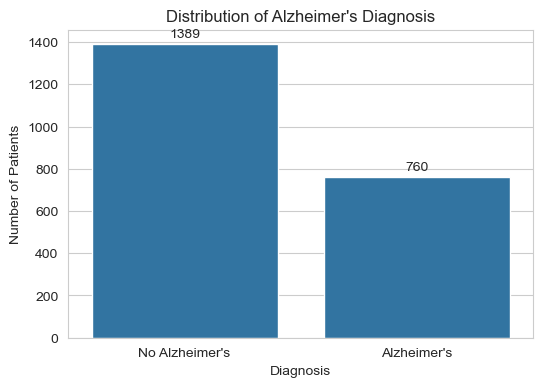

In [17]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="Diagnosis",
    data=df
)

plt.title("Distribution of Alzheimer's Diagnosis")

plt.xlabel("Diagnosis")

plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1],
    labels=["No Alzheimer's","Alzheimer's"]
)

# Display count values
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.show()

## Summary Statistics of Age

In [18]:
df["Age"].describe()

count    2149.000000
mean       74.908795
std         8.990221
min        60.000000
25%        67.000000
50%        75.000000
75%        83.000000
max        90.000000
Name: Age, dtype: float64

## Histogram of Age

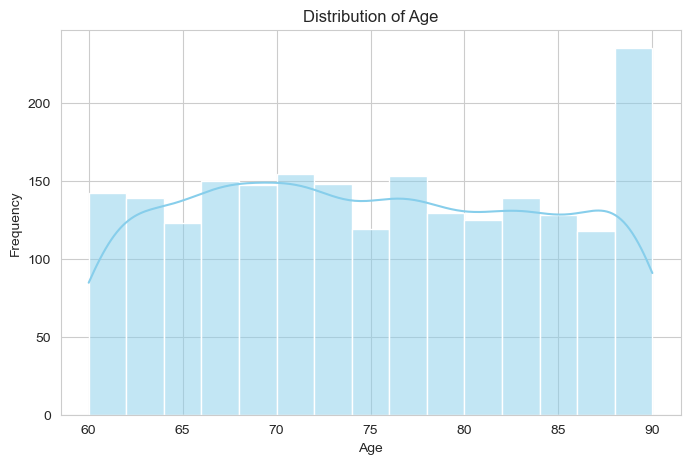

In [19]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

## Check Skewness

In [20]:
print(df["Age"].skew())

0.04596434063152629


## Analyze Gender

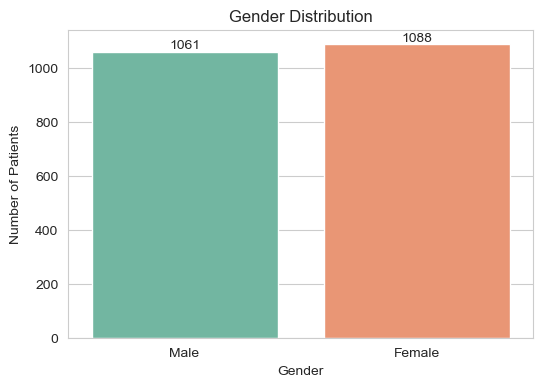

In [21]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Gender",
    palette="Set2"
)

plt.xticks(
    ticks=[0,1],
    labels=["Male","Female"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Patients")

plt.show()

## Remaining Numerical Columns

In [22]:
remaining_numerical_columns = [
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

## Summary Statistics

In [23]:
df[remaining_numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840
SystolicBP,2149.0,134.264774,25.949352,90.000000,112.000000,134.000000,157.000000,179.000000
DiastolicBP,2149.0,89.847836,17.592496,60.000000,74.000000,91.000000,105.000000,119.000000
CholesterolTotal,2149.0,225.197519,42.542233,150.093316,190.252963,225.086430,262.031657,299.993352
CholesterolLDL,2149.0,124.335944,43.366584,50.230707,87.195798,123.342593,161.733733,199.965665
CholesterolHDL,2149.0,59.463533,23.139174,20.003434,39.095698,59.768237,78.939050,99.980324


## Boxplots

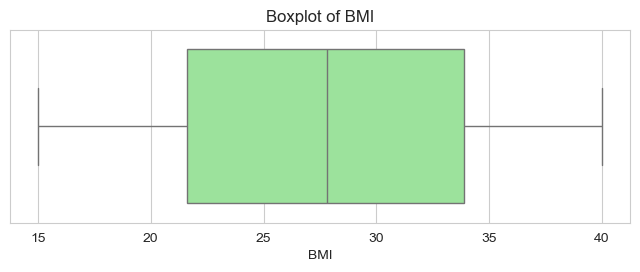

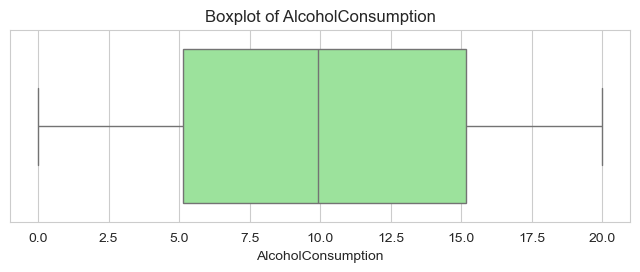

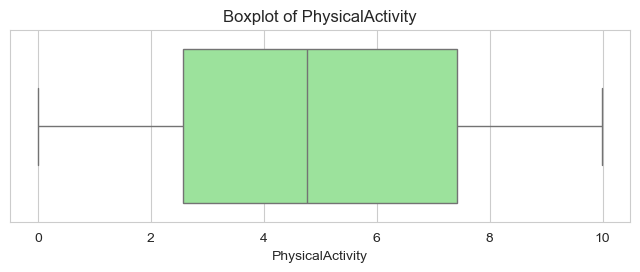

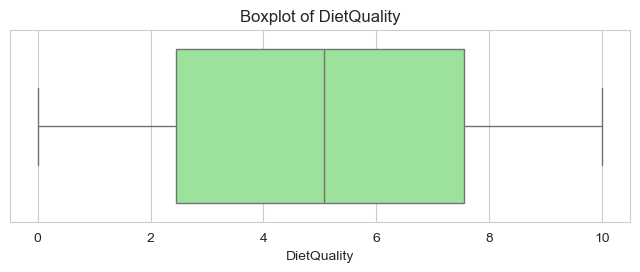

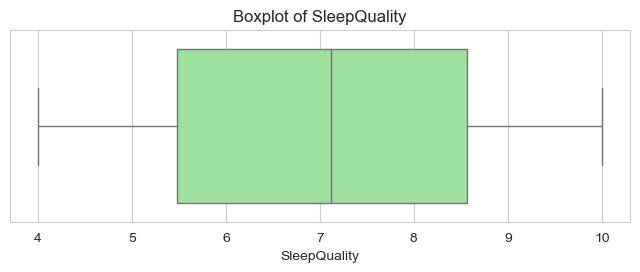

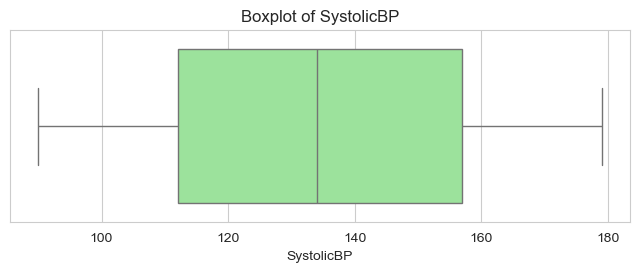

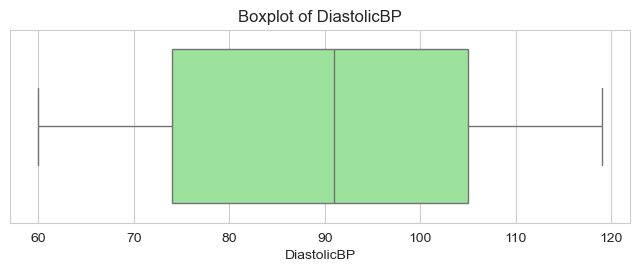

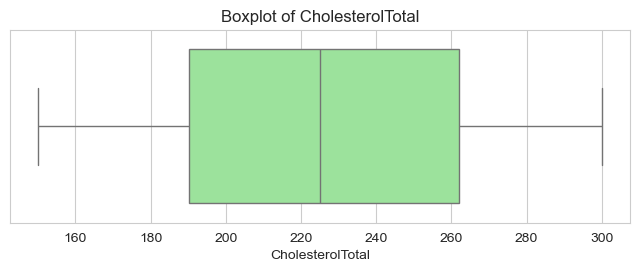

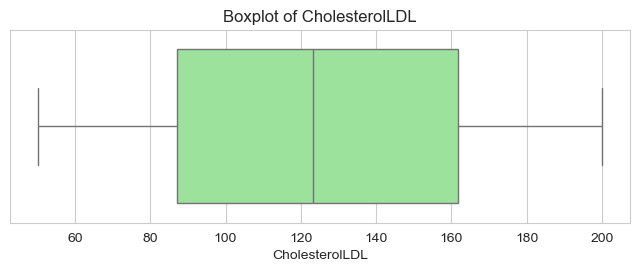

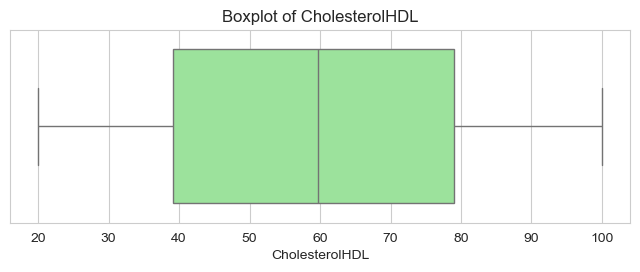

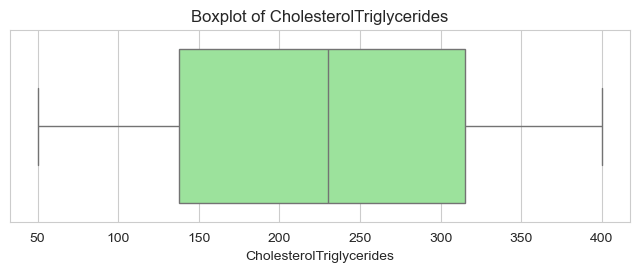

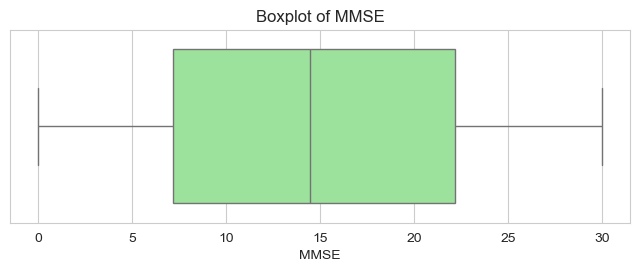

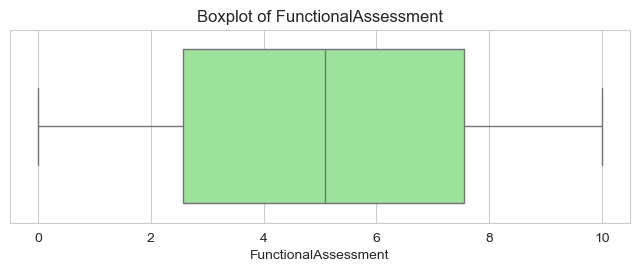

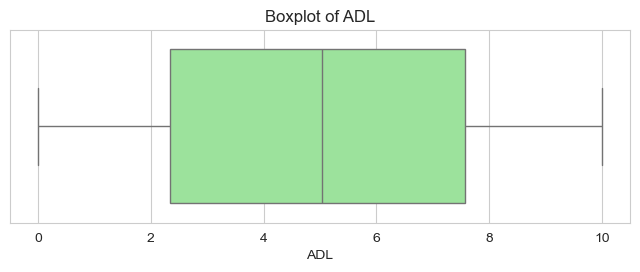

In [24]:
for column in remaining_numerical_columns:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(
        x=df[column],
        color="lightgreen"
    )

    plt.title(f"Boxplot of {column}")

    plt.xlabel(column)

    plt.show()

## Skewness

In [25]:
df[remaining_numerical_columns].skew().sort_values()

SleepQuality               -0.069630
DiastolicBP                -0.054470
FunctionalAssessment       -0.034576
CholesterolTriglycerides   -0.032923
ADL                        -0.030436
BMI                        -0.026715
CholesterolTotal           -0.018674
DietQuality                -0.012058
SystolicBP                  0.009971
AlcoholConsumption          0.018415
MMSE                        0.032382
CholesterolLDL              0.036233
CholesterolHDL              0.042206
PhysicalActivity            0.044973
dtype: float64

## Bivariate Analysis
## A - Numerical Features vs Diagnosis

## Define Numerical Columns

In [26]:
numerical_columns = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

## C – Correlation Analysis

In [27]:
correlation = df.corr(numeric_only=True)
correlation.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
Age,1.000000,0.028708,0.027745,-0.060560,-0.015677,0.020060,0.007323,-0.010249,-0.023386,0.049139,...,0.005508,0.012343,0.038973,-0.038658,0.009002,0.027523,-0.009470,0.013900,-0.019279,-0.005488
Gender,0.028708,1.000000,-0.003660,-0.007070,0.005928,0.016650,0.004330,-0.035795,0.010942,0.007310,...,0.033324,0.003880,0.006099,0.003865,-0.030583,0.017506,0.025919,-0.001636,-0.028537,-0.020975
Ethnicity,0.027745,-0.003660,1.000000,0.026516,-0.003176,0.031485,0.008363,0.020498,-0.018184,0.029304,...,-0.004704,0.003687,-0.019363,0.010475,0.022431,-0.018132,-0.030035,0.019363,-0.034619,-0.014782
EducationLevel,-0.060560,-0.007070,0.026516,1.000000,-0.023514,-0.009904,-0.012646,-0.016703,0.017412,0.020248,...,0.020269,-0.000165,0.010473,0.031934,-0.008168,-0.017568,-0.019950,0.013033,-0.008685,-0.043966
BMI,-0.015677,0.005928,-0.003176,-0.023514,1.000000,0.020437,-0.008997,0.000742,0.019922,-0.005975,...,-0.030501,0.029293,0.035276,-0.009788,-0.015859,-0.031840,-0.015901,-0.039400,0.071131,0.026343


## Heatmap

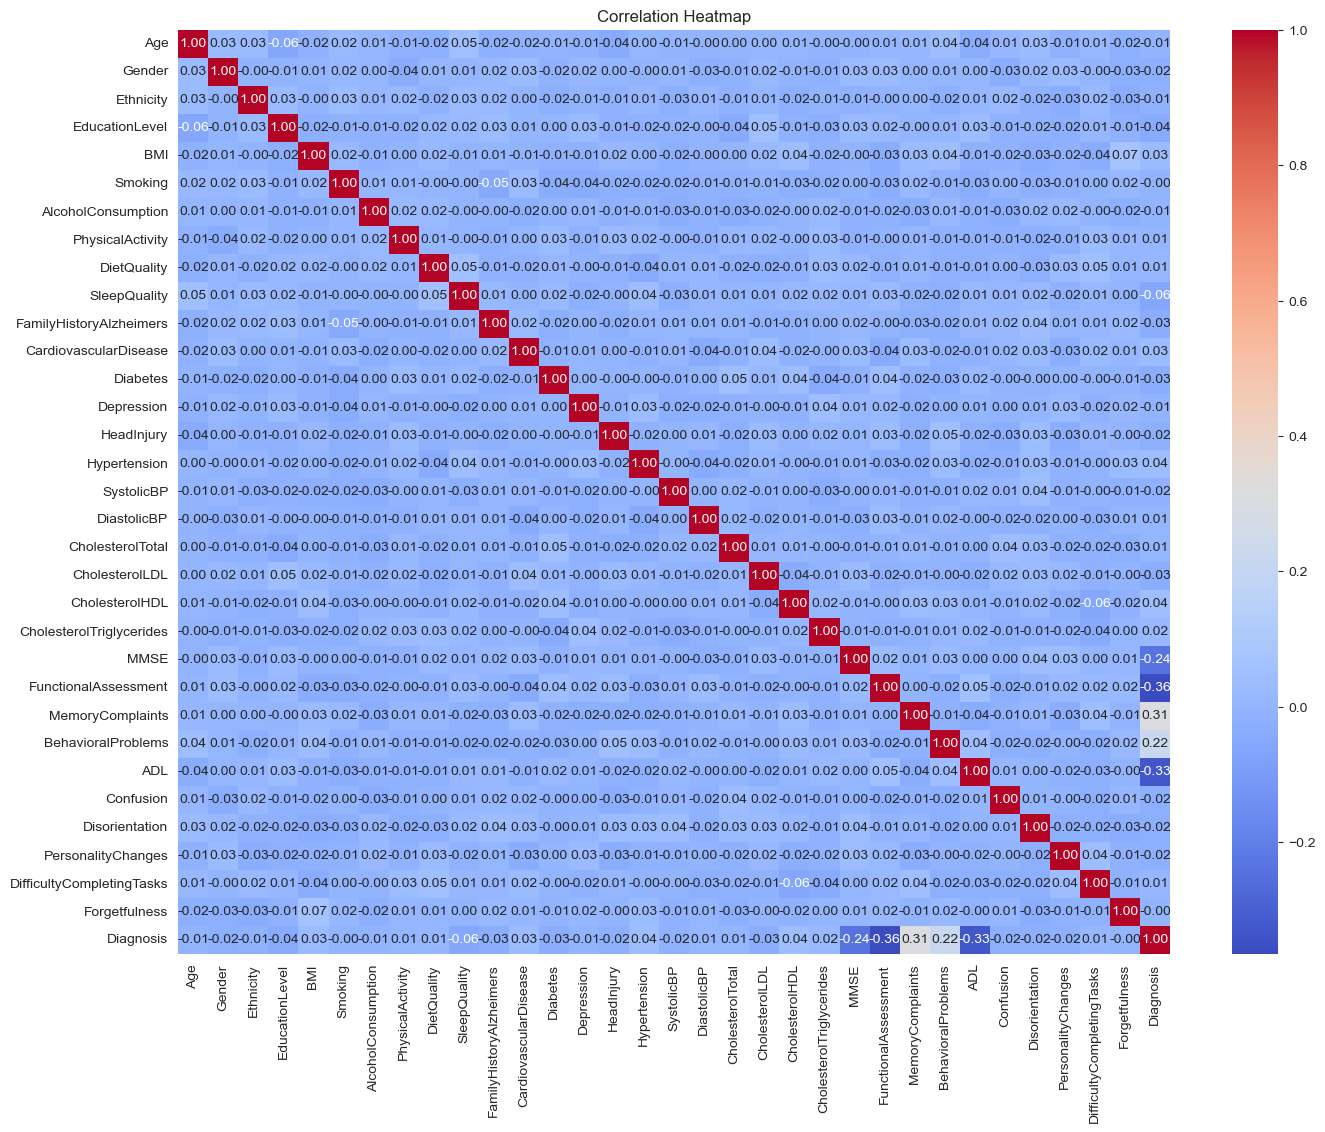

In [28]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Feature Engineering & Data Preprocessing

## Separate Features and Target

## Create X and y

In [29]:
X = df.drop("Diagnosis", axis=1)

y = df["Diagnosis"]

## Verify

In [30]:
print(X.shape)

print(y.shape)

(2149, 32)
(2149,)


## Display First Rows

In [31]:
X.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,13.517609,6.045039,0,0,0.014691,0,0,1,1,0


In [32]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Diagnosis, dtype: int64

## Check Target Balance

In [33]:
y.value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

## Train-Test Split & Feature Scaling

## Split the Dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Verify the Split

In [35]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (1719, 32)
X_test Shape  : (430, 32)
y_train Shape : (1719,)
y_test Shape  : (430,)


## Check Class Distribution

In [36]:
print(y_train.value_counts(normalize=True) * 100)

print()

print(y_test.value_counts(normalize=True) * 100)

Diagnosis
0    64.630599
1    35.369401
Name: proportion, dtype: float64

Diagnosis
0    64.651163
1    35.348837
Name: proportion, dtype: float64


## Create the Scaler

In [37]:
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


## Fit and Transform the Training Data

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

## Transform the Testing Data

In [39]:
X_test_scaled = scaler.transform(X_test)

## Check the Output

In [40]:
print(type(X_train_scaled))
print(type(X_test_scaled))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## Verify the Shape

In [41]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1719, 32)
(430, 32)


# Part-2 Model Buliding And Evaluation

## MODEL_1 RANDOM FOREST ALGO

### Import Required Libraries

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import(
 accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

### Check Training and Testing Data

In [43]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (1719, 32)
Testing Features Shape  : (430, 32)
Training Labels Shape   : (1719,)
Testing Labels Shape    : (430,)


### Create the Random Forest Model

In [44]:
rf_model = RandomForestClassifier(

    # Number of decision trees
    n_estimators=100,

    # Split criterion
    criterion='gini',

    # Maximum depth of each tree
    max_depth=None,

    # Minimum samples required to split a node
    min_samples_split=2,

    # Minimum samples required in a leaf node
    min_samples_leaf=1,

    # Number of features considered at each split
    max_features='sqrt',

    # Bootstrap sampling
    bootstrap=True,

    # Random seed for reproducibility
    random_state=42

)

### Train the Model

In [45]:
print("Training Random Forest Model...")
rf_model.fit(X_train, y_train)
print("Training Completed Successfully!")
y_test

Training Random Forest Model...
Training Completed Successfully!


451     1
2080    1
1656    1
1070    1
830     1
       ..
1797    0
1424    0
108     1
1816    0
162     0
Name: Diagnosis, Length: 430, dtype: int64

### Predict the Test Data

In [46]:
print("Making Predictions...")
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]
print("Prediction Completed!")
y_pred

Making Predictions...
Prediction Completed!


array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

### Display Actual vs Predicted Values

In [47]:
comparison = pd.DataFrame({
    "Actual Value": y_test,
    "Predicted Value": y_pred
})
print(comparison.head(20))

      Actual Value  Predicted Value
451              1                1
2080             1                0
1656             1                1
1070             1                0
830              1                1
1254             0                0
1449             1                1
1910             0                0
1627             0                0
501              1                1
1727             0                0
365              1                1
801              0                0
2031             0                1
707              0                0
1721             0                0
220              0                0
1347             0                0
1468             0                0
46               1                1


### Model Evaluation

In [48]:
accuracy_rf =  accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy_rf)
precision_rf = precision_score(y_test, y_pred)
print('Precision:', precision_rf)
recall_rf = recall_score(y_test, y_pred)
print('Recall:', recall_rf)
f1_rf = f1_score(y_test,y_pred)
print('F1 score:', f1_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob)
print('ROC-AUC Score:', roc_auc_rf)

Accuracy: 0.9372093023255814
Precision: 0.9370629370629371
Recall: 0.881578947368421
F1 score: 0.9084745762711864
ROC-AUC Score: 0.9390382430897388


### Confusion Matrix

In [49]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[269   9]
 [ 18 134]]


### Plot Confusion Matrix

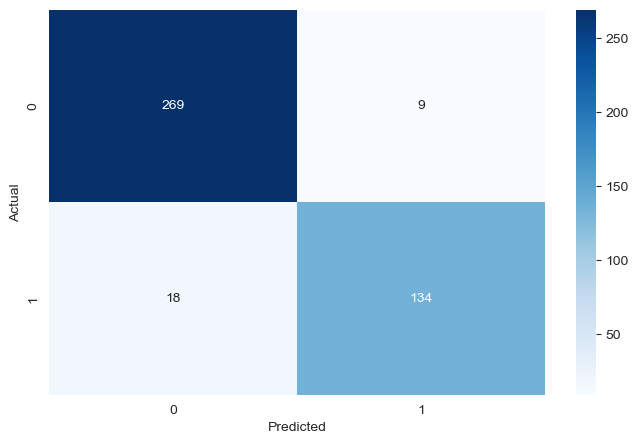

In [50]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Classification Report

In [51]:
report = classification_report(
    y_test,
    y_pred
)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



In [53]:
print('Training Accuracy:', rf_model.score(X_train, y_train))
print('Testing Accuracy:', rf_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9372093023255814


# MODEL 2-LOGISTIC REGRESSION

### Create the Logistic Regression Model

In [54]:
lr_model = LogisticRegression(

    # Maximum number of iterations
    max_iter=1000,

    # Optimization algorithm
    solver='lbfgs',

    # Regularization strength
    C=1.0,

    # L2 Regularization
    penalty='l2',

    # Random seed
    random_state=42

)

### Train the Logistic Regression Model

In [55]:
print("Training Logistic Regression Model...")
lr_model.fit(X_train_scaled, y_train)
print("Training Completed Successfully!")
y_train

Training Logistic Regression Model...
Training Completed Successfully!


780     0
1341    0
820     1
857     0
593     0
       ..
1317    1
711     0
199     0
319     1
802     0
Name: Diagnosis, Length: 1719, dtype: int64

### Predict Test Data

In [56]:
print("Making Predictions...")
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]
print("Prediction Completed!")
y_pred

Making Predictions...
Prediction Completed!


array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

### Compare Actual and Predicted Values

In [57]:
comparison = pd.DataFrame({

    "Actual Value": y_test,

    "Predicted Value": y_pred_lr

})

print(comparison.head(20))

      Actual Value  Predicted Value
451              1                1
2080             1                0
1656             1                1
1070             1                0
830              1                1
1254             0                0
1449             1                1
1910             0                0
1627             0                1
501              1                1
1727             0                0
365              1                1
801              0                0
2031             0                0
707              0                1
1721             0                0
220              0                0
1347             0                0
1468             0                0
46               1                1


### Model Evaluation

In [58]:
accuracy_lr =  accuracy_score(y_test, y_pred_lr)
print('Accuracy:', accuracy_lr)
precision_lr = precision_score(y_test, y_pred_lr)
print('Precision:', precision_lr)
recall_lr = recall_score(y_test, y_pred_lr)
print('Recall:', recall_lr)
f1_lr = f1_score(y_test,y_pred_lr)
print('F1 score:', f1_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print('ROC-AUC Score:', roc_auc_lr)

Accuracy: 0.8162790697674419
Precision: 0.7417218543046358
Recall: 0.7368421052631579
F1 score: 0.7392739273927392
ROC-AUC Score: 0.8853653918970088


### Generate Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[239  39]
 [ 40 112]]


### Visualize Confusion Matrix

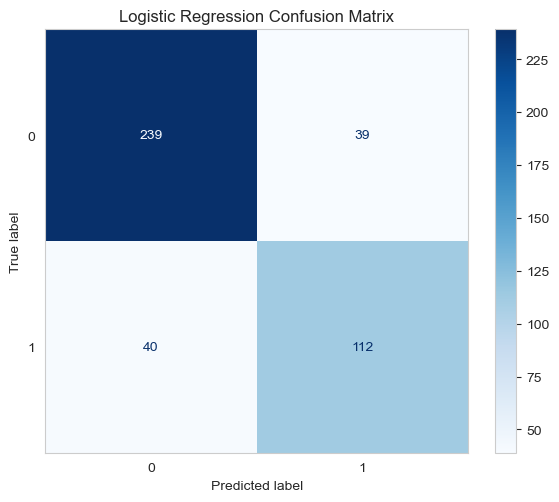

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)

# Remove white grid lines
ax.grid(False)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### Classification Report

In [61]:
report = classification_report(

    y_test,

    y_pred_lr

)

print(report)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



In [63]:
print('Training Accuracy:', lr_model.score(X_train_scaled, y_train))
print('Testing Accuracy:', lr_model.score(X_test_scaled, y_test))

Training Accuracy: 0.8510762070971495
Testing Accuracy: 0.8162790697674419


In [64]:
!pip install xgboost

# MODEL 3-XG BOOST

### Create the XGBoost Model

In [65]:
xgb_model = XGBClassifier(

    # Number of boosting rounds (trees)
    n_estimators=100,

    # Learning rate
    learning_rate=0.1,

    # Maximum depth of each tree
    max_depth=6,

    # Minimum loss reduction
    gamma=0,

    # Minimum child weight
    min_child_weight=1,

    # Row sampling ratio
    subsample=0.8,

    # Feature sampling ratio
    colsample_bytree=0.8,

    # Objective function
    objective='binary:logistic',

    # Evaluation metric
    eval_metric='logloss',

    # Random seed
    random_state=42
)

### Train the XGBoost Model

In [66]:
print("Training XGBoost Model...")
xgb_model.fit(X_train, y_train)
print("Training Completed Successfully!")
y_test

Training XGBoost Model...
Training Completed Successfully!


451     1
2080    1
1656    1
1070    1
830     1
       ..
1797    0
1424    0
108     1
1816    0
162     0
Name: Diagnosis, Length: 430, dtype: int64

### Predict Test Data

In [67]:
print("Making Predictions...")
y_pred_xg = xgb_model.predict(X_test)
y_prob_xg = xgb_model.predict_proba(X_test)[:, 1]
print("Prediction Completed!")
y_pred

Making Predictions...
Prediction Completed!


array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,

### Compare Actual and Predicted Values

In [68]:
comparison = pd.DataFrame({

    "Actual Value": y_test,

    "Predicted Value": y_pred_xg

})

print(comparison.head(20))

      Actual Value  Predicted Value
451              1                1
2080             1                0
1656             1                1
1070             1                1
830              1                1
1254             0                0
1449             1                1
1910             0                0
1627             0                0
501              1                1
1727             0                0
365              1                1
801              0                0
2031             0                1
707              0                0
1721             0                0
220              0                0
1347             0                0
1468             0                0
46               1                1


### Model Evaluation

In [69]:
accuracy_xg =  accuracy_score(y_test, y_pred_xg)
print('Accuracy:', accuracy_xg)
precision_xg = precision_score(y_test, y_pred_xg)
print('Precision:', precision_xg)
recall_xg = recall_score(y_test, y_pred_xg)
print('Recall:', recall_xg)
f1_xg = f1_score(y_test,y_pred_xg)
print('F1 score:', f1_xg)
roc_auc_xg = roc_auc_score(y_test, y_prob_xg)
print('ROC-AUC Score:', roc_auc_xg)

Accuracy: 0.9511627906976744
Precision: 0.9455782312925171
Recall: 0.9144736842105263
F1 score: 0.9297658862876255
ROC-AUC Score: 0.9406001514577812


### Generate Confusion Matrix

In [70]:
cm = confusion_matrix(y_test, y_pred_xg)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[270   8]
 [ 13 139]]


### Plot Confusion Matrix

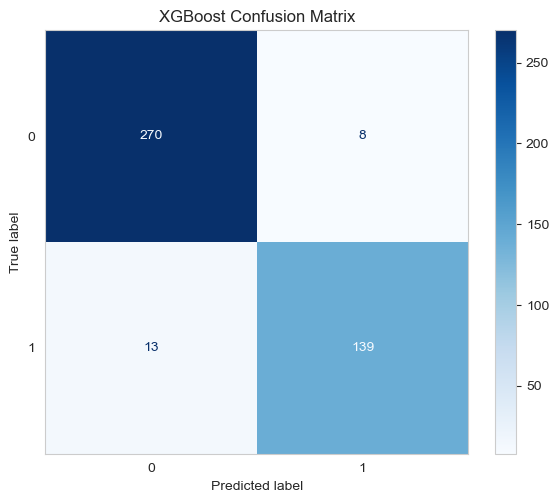

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.grid(False)
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

### Classification Report

In [72]:
report = classification_report(
    y_test,
    y_pred_xg
)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



In [73]:
print('Training Accuracy:', xgb_model.score(X_train, y_train))
print('Testing Accuracy:', xgb_model.score(X_test, y_test))

Training Accuracy: 0.9988365328679465
Testing Accuracy: 0.9511627906976744


In [74]:
import pandas as pd
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "XGBoost"],
    "Accuracy": [accuracy_rf, accuracy_lr, accuracy_xg],
    "Precision": [precision_rf, precision_lr, precision_xg],
    "Recall": [recall_rf, recall_lr, recall_xg],
    "F1 Score": [f1_rf, f1_lr, f1_xg]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.937209,0.937063,0.881579,0.908475
1,Logistic Regression,0.816279,0.741722,0.736842,0.739274
2,XGBoost,0.951163,0.945578,0.914474,0.929766


## Conclusion

#### Among the three machine learning models, **XGBoost** achieved the best overall performance for Alzheimer's Disease Classification. It obtained the **highest Accuracy (95.12%)**, **Precision (94.56%)**, **Recall (91.45%)**, **F1-Score (92.98%)**, and **ROC-AUC (94.06%)**, outperforming both Random Forest and Logistic Regression. These results indicate that XGBoost provides the most accurate, reliable, and balanced predictions for this dataset. Therefore, **XGBoost is selected as the final model** for Alzheimer's Disease Classification due to its superior predictive performance across all evaluation metrics.


In [78]:
import pickle

In [82]:
file = 'xgb10.pkl'

In [83]:
pickle.dump(xgb_model,open(file,'wb'))